# Notebook: CNN para Imágenes Médicas — BreastMNIST (ecografías mamarias)
Este notebook aborda el caso BreastMNIST, un dataset de imágenes médicas de mama en escala de grises con clasificación binaria (normal/benigno vs. maligno).
En este trabajo se desarrollan las siguientes mejoras:
1. Arquitectura mejorada: se incorpora Batch Normalization, Dropout y un mayor número de filtros convolucionales para evaluar su impacto en el desempeño del modelo.
2. Learning rate y scheduler: se experimenta con diferentes tasas de aprendizaje y estrategias de ajuste dinámico para mejorar el proceso de optimización.
3. Impacto del data augmentation: se comparan diferentes niveles de aumento de datos para analizar su efecto sobre la capacidad de generalización.
4. Calibración de probabilidades y curvas ROC: se implementa calibración mediante temperature scaling y se evalúa el comportamiento del clasificador mediante curvas ROC y ROC-AUC.

**Sobre el tamaño del dataset**: BreastMNIST es un dataset pequeño compuesto por 780 imágenes (546 entrenamiento, 78 validación y 156 prueba). Debido al reducido número de muestras de validación, las métricas por época pueden presentar variaciones o pequeños saltos, ya que cada predicción tiene un impacto significativo sobre el resultado final.
Estas fluctuaciones son esperables en datasets pequeños y no necesariamente indican un error en la implementación. Por ello, el análisis del modelo se realiza considerando la tendencia general de las curvas de entrenamiento y validación, además de métricas complementarias como ROC-AUC y calibración de probabilidades.



## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Normalización por lotes (BatchNorm)**
- Normaliza las activaciones de cada mini-batch.
- Acelera y estabiliza el entrenamiento, permite usar learning rates más altos.

**(c) Regularización (Dropout)**
- Apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento.
- Reduce el sobreajuste, especialmente importante con datasets chicos como BreastMNIST.

**(d) Activación (ReLU)**
- Introduce no linealidad. ReLU(x) = max(0, x).

**(e) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.

**(f) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (nódulos, márgenes irregulares, cambios de ecogenicidad).
- Aprenden representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar el rendimiento con pocos datos — algo clave en BreastMNIST, que tiene muy pocas imágenes.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos, y `medmnist` para descargar el dataset.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (BreastMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset de este ejercicio:
- Entrada: imágenes 2D (ecografías mamarias) de tamaño pequeño (28×28, escala de grises).
- Etiquetas: clasificación binaria (normal/benigno vs. maligno).
- Particiones: train/val/test ya vienen definidas (546 / 78 / 156 aprox.).


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 560k/560k [00:01<00:00, 441kB/s]


(546, 78, 156)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


Clases disponibles: {'0': 'malignant', '1': 'normal, benign'}


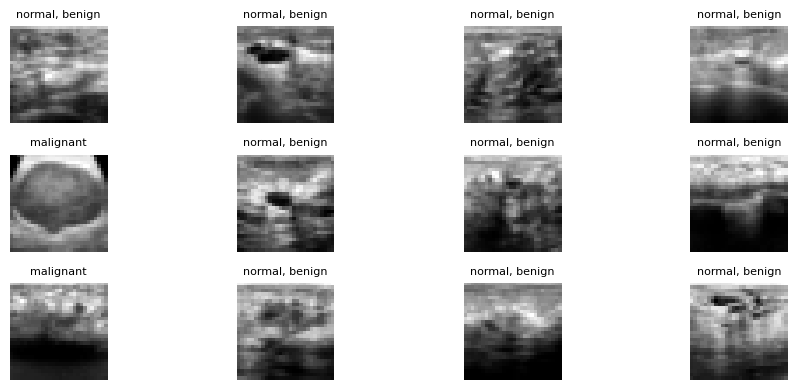

In [4]:
def label_to_name(y):
    # Convierte la etiqueta (tensor, array de numpy o int) al nombre de clase, usando info["label"]
    if hasattr(y, "item"):
        y = y.item()
    y = int(y)
    # info["label"] normalmente trae las claves como string ("0", "1"); por las dudas
    # probamos también con la clave como int, para que funcione con cualquier versión de medmnist.
    return info["label"].get(str(y), info["label"].get(y, str(y)))

def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(label_to_name(y), fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Clases disponibles:", info["label"])
show_batch(train_dataset)


### 3.2. Balance de clases

Con datasets chicos como BreastMNIST, es importante revisar si las clases están balanceadas: si una clase domina, el modelo puede **hacer trampa** prediciendo siempre la mayoritaria.


In [5]:
labels_train = np.array([int(train_dataset[i][1].item()) for i in range(len(train_dataset))])
unique, counts = np.unique(labels_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Clase {u} ({info['label'][str(u)]}): {c} muestras ({c/len(labels_train)*100:.1f}%)")


Clase 0 (malignant): 147 muestras (26.9%)
Clase 1 (normal, benign): 399 muestras (73.1%)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe. Usamos un `batch_size` más chico  porque el dataset tiene muchas menos muestras.


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [7]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(info["label"])
num_classes


2

## 5. Funciones de entrenamiento y evaluación

Estas funciones se reutilizan para todos los modelos de este notebook. **También calculamos `val_loss`** (no solo `train_loss`), para poder graficar train vs. validación y detectar sobreajuste con más claridad.


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    all_logits = []
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        if criterion is not None:
            losses.append(criterion(logits, y).item())

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_logits.append(logits.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    y_logits = np.concatenate(all_logits)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    val_loss = float(np.mean(losses)) if losses else None
    return {"acc": acc, "auc": auc, "loss": val_loss,
            "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob, "y_logits": y_logits}

def train_one_epoch(model, loader, optimizer, criterion, clip_grad_norm=None):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

def run_training(model, train_loader, val_loader, optimizer, criterion, epochs, scheduler=None, desc="", patience=6, clip_grad_norm=None):
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}
    best_val_loss = float("inf")
    epochs_sin_mejora = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, clip_grad_norm=clip_grad_norm)
        val_metrics = evaluate(model, val_loader, criterion)
        # ... el resto de la función queda exactamente igual que ya lo tenías (early stopping incluido)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_auc"].append(val_metrics["auc"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            # ReduceLROnPlateau necesita una métrica; el resto se step() sin argumento
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metrics["loss"])
            else:
                scheduler.step()

        print(f"[{desc}] Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
              f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | "
              f"val_auc={val_metrics['auc']:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")
    return history

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train loss")
    axes[0].plot(history["val_loss"], label="Val loss")
    axes[0].set_title(f"Pérdida ({title})")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["val_acc"], label="Val Accuracy")
    axes[1].plot(history["val_auc"], label="Val ROC-AUC")
    axes[1].set_title(f"Métricas de validación ({title})")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Valor")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 6. Modelo 1: CNN básica (baseline)

Primero replicamos la arquitectura simple original, sin BatchNorm ni Dropout, como punto de comparación (baseline) .


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_baseline = SimpleCNN(num_classes=num_classes).to(device)
model_baseline


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 22
history_baseline = run_training(model_baseline, train_loader, val_loader, optimizer, criterion,
                                 epochs=epochs, desc="baseline")


[baseline] Epoch 01 | train_loss=0.6046 | val_loss=0.6403 | val_acc=0.7308 | val_auc=0.5330 | lr=1.00e-03
[baseline] Epoch 02 | train_loss=0.5830 | val_loss=0.6147 | val_acc=0.7308 | val_auc=0.5338 | lr=1.00e-03
[baseline] Epoch 03 | train_loss=0.5772 | val_loss=0.6131 | val_acc=0.7308 | val_auc=0.5380 | lr=1.00e-03
[baseline] Epoch 04 | train_loss=0.5716 | val_loss=0.6292 | val_acc=0.7308 | val_auc=0.5388 | lr=1.00e-03
[baseline] Epoch 05 | train_loss=0.5724 | val_loss=0.6167 | val_acc=0.7308 | val_auc=0.5472 | lr=1.00e-03
[baseline] Epoch 06 | train_loss=0.5756 | val_loss=0.6199 | val_acc=0.7308 | val_auc=0.5522 | lr=1.00e-03
[baseline] Epoch 07 | train_loss=0.5754 | val_loss=0.6156 | val_acc=0.7308 | val_auc=0.5539 | lr=1.00e-03
[baseline] Epoch 08 | train_loss=0.5713 | val_loss=0.6135 | val_acc=0.7308 | val_auc=0.5530 | lr=1.00e-03
[baseline] Epoch 09 | train_loss=0.5725 | val_loss=0.6181 | val_acc=0.7308 | val_auc=0.5556 | lr=1.00e-03
[baseline] Epoch 10 | train_loss=0.5704 | val_

**Sobre los picos en las curvas de entrenamiento**

Que una curva presente pequeñas variaciones no significa que el entrenamiento sea incorrecto. Lo importante es analizar la tendencia general de la pérdida y observar el comportamiento entre train_loss y val_loss. Una separación creciente entre ambas curvas podría indicar sobreajuste.
En este caso, las fluctuaciones observadas son esperables debido al tamaño reducido de BreastMNIST (546 imágenes de entrenamiento y 78 de validación). Al contar con pocos datos, algunos errores de clasificación pueden generar cambios visibles en las métricas de validación.
La CNN básica muestra una disminución progresiva de la pérdida de entrenamiento, mientras que la pérdida de validación mantiene un comportamiento estable con algunas variaciones. No se observan señales claras de sobreajuste severo, aunque el desempeño del modelo presenta una mejora limitada en las métricas de validación.

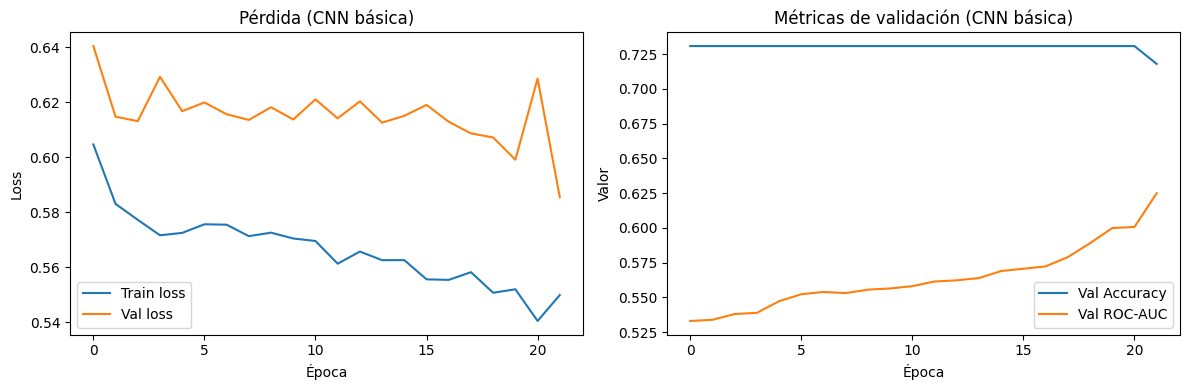

In [11]:
plot_history(history_baseline, "CNN básica")


## 7.  Arquitectura mejorada: BatchNorm + Dropout + más filtros

Ahora construimos una segunda arquitectura, `ImprovedCNN`, con tres cambios respecto a la básica:

- **Más filtros** en cada bloque convolucional (32 → 64 → 128 en vez de 16 → 32 → 64).
- **BatchNorm** después de cada convolución, para estabilizar y acelerar el entrenamiento.
- **Dropout** antes de la capa final, para reducir el sobreajuste (crítico en un dataset tan chico).

Esta será la arquitectura "base" que usamos en el resto del notebook (secciones de LR/scheduler, augmentation y transfer learning).


In [12]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_improved = ImprovedCNN(num_classes=num_classes).to(device)
model_improved


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model_improved.parameters(), lr=3e-4, weight_decay=1e-4)

epochs = 22
history_improved = run_training(model_improved, train_loader, val_loader, optimizer, criterion,
                                 epochs=epochs, desc="improved", clip_grad_norm=1.0)

[improved] Epoch 01 | train_loss=0.6272 | val_loss=0.6773 | val_acc=0.7308 | val_auc=0.6249 | lr=3.00e-04
[improved] Epoch 02 | train_loss=0.5582 | val_loss=0.6729 | val_acc=0.7308 | val_auc=0.6658 | lr=3.00e-04
[improved] Epoch 03 | train_loss=0.5259 | val_loss=0.6870 | val_acc=0.4359 | val_auc=0.7728 | lr=3.00e-04
[improved] Epoch 04 | train_loss=0.5014 | val_loss=0.6894 | val_acc=0.4231 | val_auc=0.8221 | lr=3.00e-04
[improved] Epoch 05 | train_loss=0.4977 | val_loss=0.6304 | val_acc=0.6026 | val_auc=0.8530 | lr=3.00e-04
[improved] Epoch 06 | train_loss=0.4881 | val_loss=0.5590 | val_acc=0.7308 | val_auc=0.9098 | lr=3.00e-04
[improved] Epoch 07 | train_loss=0.4760 | val_loss=0.4622 | val_acc=0.8205 | val_auc=0.8663 | lr=3.00e-04
[improved] Epoch 08 | train_loss=0.4636 | val_loss=0.4266 | val_acc=0.8333 | val_auc=0.9165 | lr=3.00e-04
[improved] Epoch 09 | train_loss=0.4591 | val_loss=0.4511 | val_acc=0.8462 | val_auc=0.8906 | lr=3.00e-04
[improved] Epoch 10 | train_loss=0.4471 | val_

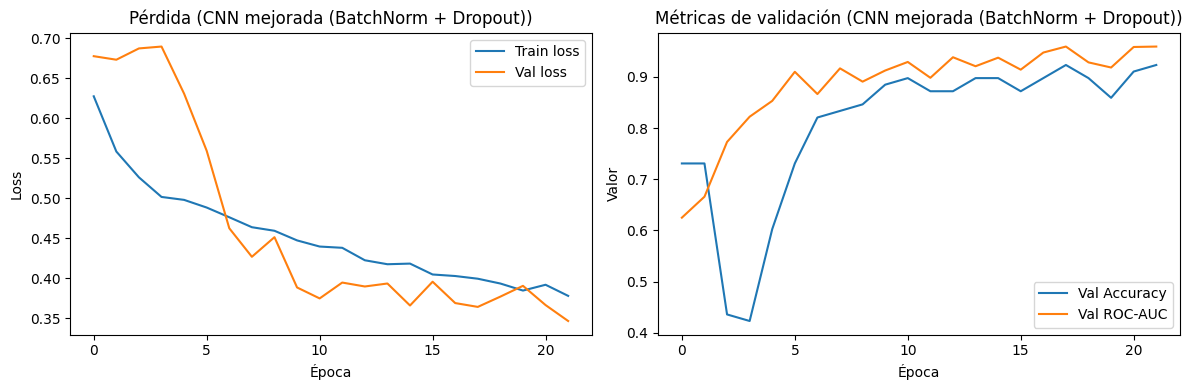

In [14]:
plot_history(history_improved, "CNN mejorada (BatchNorm + Dropout)")


**Análisis de las curvas de entrenamiento:** La CNN mejorada con BatchNorm y Dropout presenta una reducción progresiva de la pérdida tanto en entrenamiento como en validación. Aunque se observan pequeñas fluctuaciones, estas son esperables debido al tamaño reducido del conjunto de validación de BreastMNIST. No se observa una separación creciente entre Train Loss y Validation Loss, por lo que no se evidencian señales claras de sobreajuste severo. Además, las métricas de validación muestran una mejora progresiva, indicando una mayor capacidad de generalización del modelo.

### 7.1. Comparación: básica vs. mejorada

Comparamos ambos modelos utilizando el conjunto de prueba (test), reservado para evaluar el desempeño final sobre imágenes no utilizadas durante el entrenamiento.

In [15]:
test_baseline = evaluate(model_baseline, test_loader, criterion)
test_improved = evaluate(model_improved, test_loader, criterion)

print(f"CNN básica    | test_acc={test_baseline['acc']:.4f} | test_auc={test_baseline['auc']:.4f}")
print(f"CNN mejorada  | test_acc={test_improved['acc']:.4f} | test_auc={test_improved['auc']:.4f}")


CNN básica    | test_acc=0.7308 | test_auc=0.6811
CNN mejorada  | test_acc=0.8526 | test_auc=0.8926


**Análisis de resultados:** La CNN mejorada presenta un mejor desempeño respecto a la CNN básica en el conjunto de prueba. Se observa un incremento en Accuracy y ROC-AUC, lo que indica una mayor capacidad del modelo para clasificar correctamente las imágenes y diferenciar entre las dos clases de BreastMNIST.
La incorporación de BatchNorm, Dropout y una arquitectura con mayor número de filtros permitió mejorar la capacidad de generalización del modelo.



7.2 Matriz de confusión del modelo final

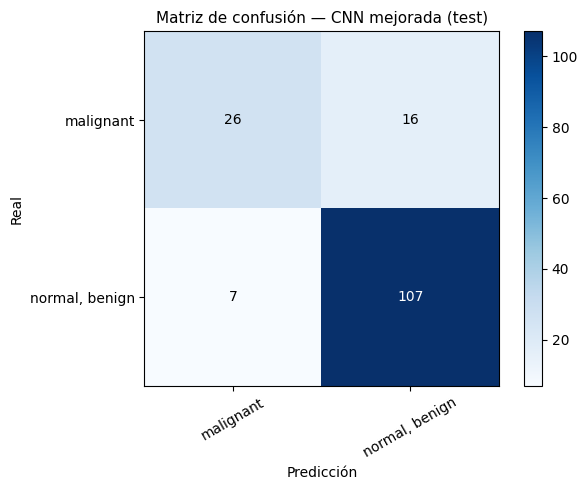

                precision    recall  f1-score   support

     malignant     0.7879    0.6190    0.6933        42
normal, benign     0.8699    0.9386    0.9030       114

      accuracy                         0.8526       156
     macro avg     0.8289    0.7788    0.7981       156
  weighted avg     0.8478    0.8526    0.8465       156



In [17]:
class_names = [info["label"][str(i)] for i in range(num_classes)]

cm_improved = confusion_matrix(test_improved["y_true"], test_improved["y_pred"])

plt.figure(figsize=(6.5, 5))
plt.imshow(cm_improved, cmap="Blues")
plt.title("Matriz de confusión — CNN mejorada (test)", fontsize=11)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(range(num_classes), class_names, rotation=30)
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_improved[i, j], ha="center", va="center",
                  color="white" if cm_improved[i, j] > cm_improved.max() / 2 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()

print(classification_report(test_improved["y_true"], test_improved["y_pred"],
                             target_names=class_names, digits=4, zero_division=0))


**La matriz de confusión** permite analizar los aciertos y errores del modelo CNN mejorado en cada clase. El modelo logra clasificar correctamente la mayoría de imágenes normales/benignas; sin embargo, presenta algunos casos malignos clasificados como benignos. Esto evidencia la importancia de complementar Accuracy con métricas como Recall y ROC-AUC para evaluar el desempeño en problemas médicos.

## 8. Experimentar con learning rate y scheduler

Comparamos cuatro configuraciones sobre la misma arquitectura (`ImprovedCNN`), entrenando cada una desde cero:

1. **LR alto fijo** (1e-2): para ver inestabilidad.
2. **LR bajo fijo** (1e-4): para ver convergencia lenta.
3. **LR medio + StepLR**: baja el LR a la mitad cada 5 épocas.
4. **LR medio + ReduceLROnPlateau**: baja el LR cuando `val_loss` deja de mejorar.


In [18]:
def make_model():
    return ImprovedCNN(num_classes=num_classes).to(device)

lr_configs = {
    "lr_alto (1e-2, fijo)": {"lr": 1e-2, "scheduler": None},
    "lr_bajo (1e-4, fijo)": {"lr": 1e-4, "scheduler": None},
    "lr_medio + StepLR": {"lr": 1e-3, "scheduler": "step"},
    "lr_medio + ReduceLROnPlateau": {"lr": 1e-3, "scheduler": "plateau"},
}

lr_histories = {}
lr_models = {}
epochs_lr = 12

for name, cfg in lr_configs.items():
    print(f"\n=== Entrenando: {name} ===")
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

    scheduler = None
    if cfg["scheduler"] == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    elif cfg["scheduler"] == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    criterion = nn.CrossEntropyLoss()
    history = run_training(model, train_loader, val_loader, optimizer, criterion,
                            epochs=epochs_lr, scheduler=scheduler, desc=name)
    lr_histories[name] = history
    lr_models[name] = model



=== Entrenando: lr_alto (1e-2, fijo) ===
[lr_alto (1e-2, fijo)] Epoch 01 | train_loss=0.6123 | val_loss=0.8257 | val_acc=0.2692 | val_auc=0.6090 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 02 | train_loss=0.4684 | val_loss=0.8932 | val_acc=0.2692 | val_auc=0.7327 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 03 | train_loss=0.4576 | val_loss=1.0573 | val_acc=0.2692 | val_auc=0.7176 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 04 | train_loss=0.4563 | val_loss=1.2197 | val_acc=0.2692 | val_auc=0.7093 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 05 | train_loss=0.4513 | val_loss=1.1053 | val_acc=0.2821 | val_auc=0.8179 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 06 | train_loss=0.4335 | val_loss=0.7208 | val_acc=0.5128 | val_auc=0.8797 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 07 | train_loss=0.4143 | val_loss=0.6888 | val_acc=0.5641 | val_auc=0.8847 | lr=1.00e-02
[lr_alto (1e-2, fijo)] Epoch 08 | train_loss=0.4019 | val_loss=0.3727 | val_acc=0.8590 | val_auc=0.8872 | lr=1.00e-02
[lr_alto (1e-2

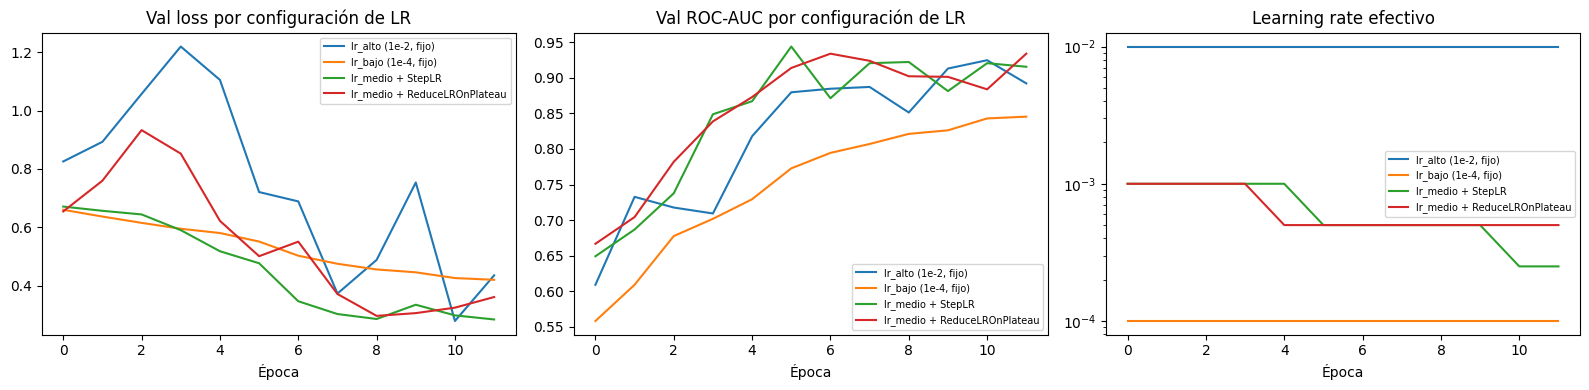

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, history in lr_histories.items():
    axes[0].plot(history["val_loss"], label=name)
    axes[1].plot(history["val_auc"], label=name)
    axes[2].plot(history["lr"], label=name)

axes[0].set_title("Val loss por configuración de LR")
axes[0].set_xlabel("Época")
axes[0].legend(fontsize=7)

axes[1].set_title("Val ROC-AUC por configuración de LR")
axes[1].set_xlabel("Época")
axes[1].legend(fontsize=7)

axes[2].set_title("Learning rate efectivo")
axes[2].set_xlabel("Época")
axes[2].set_yscale("log")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()


**Análisis del learning rate y scheduler:**
Se observa que diferentes tasas de aprendizaje generan variaciones en la estabilidad del entrenamiento. El learning rate elevado presenta mayores oscilaciones, mientras que las configuraciones con scheduler permiten ajustar progresivamente la tasa de aprendizaje y obtener un comportamiento más estable. Debido al tamaño reducido de BreastMNIST, pequeñas variaciones entre épocas son esperables.

In [20]:
print("Resumen en test por configuración de LR/scheduler")
for name, model in lr_models.items():
    m = evaluate(model, test_loader, criterion)
    print(f"{name:32s} | test_acc={m['acc']:.4f} | test_auc={m['auc']:.4f}")


Resumen en test por configuración de LR/scheduler
lr_alto (1e-2, fijo)             | test_acc=0.7821 | test_auc=0.8517
lr_bajo (1e-4, fijo)             | test_acc=0.7885 | test_auc=0.8216
lr_medio + StepLR                | test_acc=0.8462 | test_auc=0.8605
lr_medio + ReduceLROnPlateau     | test_acc=0.7949 | test_auc=0.8897


**Interpretación**

El experimento muestra que la elección del learning rate influye en la estabilidad y desempeño del modelo. El learning rate alto (1e-2) presentó mayores variaciones durante el entrenamiento, mientras que el learning rate bajo (1e-4) mostró un aprendizaje más estable pero con menor capacidad de discriminación.
Las configuraciones con scheduler lograron mejores resultados. StepLR obtuvo la mayor Accuracy (0.8462), mientras que ReduceLROnPlateau alcanzó el mayor ROC-AUC (0.8897), indicando una mejor capacidad para diferenciar entre las clases.
Estos resultados muestran que ajustar dinámicamente la tasa de aprendizaje puede mejorar el proceso de optimización, especialmente en datasets pequeños como BreastMNIST.Con más épocas, lr_bajo probablemente seguiría mejorando, pero incluso así confirma que converge más lento que las configuraciones con scheduler


## 9.  Impacto de diferentes aumentos de datos (data augmentation)

Comparamos tres niveles de augmentation, todos entrenando la misma arquitectura (`ImprovedCNN`) con la mejor configuración de LR/scheduler encontrada arriba (LR medio + scheduler):

1. **Sin augmentation**: solo `ToTensor()`.
2. **Augmentation leve**: rotaciones pequeñas + traslaciones suaves (igual al notebook original).
3. **Augmentation fuerte**: rotaciones más grandes, flips horizontales y variación de brillo/contraste.

⚠️ En imágenes médicas hay que tener cuidado: un flip horizontal puede tener sentido en una ecografía (no hay una orientación anatómica fija como en una radiografía de tórax), pero en otros estudios podría invalidar la imagen. Aquí lo usamos a modo de comparación experimental.


In [21]:
transform_none = T.Compose([
    T.ToTensor()
])

transform_light = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

transform_strong = T.Compose([
    T.RandomRotation(degrees=20),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor()
])

aug_configs = {
    "sin_augmentation": transform_none,
    "augmentation_leve": transform_light,
    "augmentation_fuerte": transform_strong,
}

aug_histories = {}
aug_models = {}
epochs_aug = 15

for name, tfm in aug_configs.items():
    print(f"\n=== Entrenando: {name} ===")
    train_dataset_variant = DataClass(split="train", transform=tfm, download=True)
    train_loader_variant = DataLoader(train_dataset_variant, batch_size=batch_size, shuffle=True,
                                       num_workers=2, pin_memory=True)

    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = run_training(model, train_loader_variant, val_loader, optimizer, criterion,
                            epochs=epochs_aug, scheduler=scheduler, desc=name)
    aug_histories[name] = history
    aug_models[name] = model



=== Entrenando: sin_augmentation ===
[sin_augmentation] Epoch 01 | train_loss=0.5440 | val_loss=0.6979 | val_acc=0.3462 | val_auc=0.6642 | lr=1.00e-03
[sin_augmentation] Epoch 02 | train_loss=0.4626 | val_loss=1.2129 | val_acc=0.2692 | val_auc=0.7794 | lr=1.00e-03
[sin_augmentation] Epoch 03 | train_loss=0.4517 | val_loss=1.3889 | val_acc=0.2692 | val_auc=0.7870 | lr=1.00e-03
[sin_augmentation] Epoch 04 | train_loss=0.4334 | val_loss=0.8312 | val_acc=0.3846 | val_auc=0.7469 | lr=1.00e-03
[sin_augmentation] Epoch 05 | train_loss=0.3910 | val_loss=0.6506 | val_acc=0.5513 | val_auc=0.8221 | lr=5.00e-04
[sin_augmentation] Epoch 06 | train_loss=0.3776 | val_loss=0.7529 | val_acc=0.4744 | val_auc=0.8864 | lr=5.00e-04
[sin_augmentation] Epoch 07 | train_loss=0.3522 | val_loss=0.4711 | val_acc=0.7051 | val_auc=0.8747 | lr=5.00e-04
[sin_augmentation] Epoch 08 | train_loss=0.3637 | val_loss=0.3289 | val_acc=0.8590 | val_auc=0.9048 | lr=5.00e-04
[sin_augmentation] Epoch 09 | train_loss=0.3459 | 

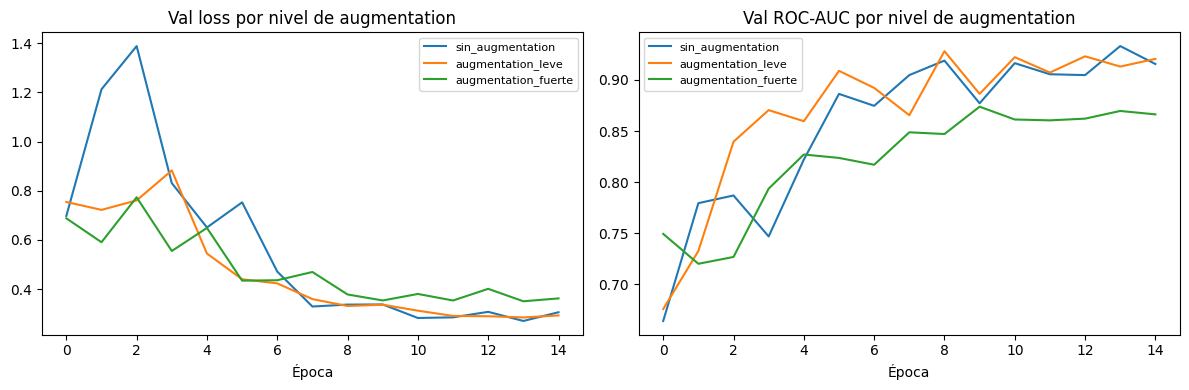

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history in aug_histories.items():
    axes[0].plot(history["val_loss"], label=name)
    axes[1].plot(history["val_auc"], label=name)

axes[0].set_title("Val loss por nivel de augmentation")
axes[0].set_xlabel("Época")
axes[0].legend(fontsize=8)

axes[1].set_title("Val ROC-AUC por nivel de augmentation")
axes[1].set_xlabel("Época")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [23]:
print("Resumen en test por nivel de augmentation")
for name, model in aug_models.items():
    m = evaluate(model, test_loader, criterion)
    print(f"{name:22s} | test_acc={m['acc']:.4f} | test_auc={m['auc']:.4f}")


Resumen en test por nivel de augmentation
sin_augmentation       | test_acc=0.8269 | test_auc=0.8647
augmentation_leve      | test_acc=0.8397 | test_auc=0.8676
augmentation_fuerte    | test_acc=0.8205 | test_auc=0.8258


**Interpretación:** En BreastMNIST, debido al tamaño reducido del dataset, el uso de data augmentation puede ayudar a mejorar la capacidad de generalización del modelo. En este experimento, el augmentation leve obtuvo el mejor desempeño, alcanzando el mayor Accuracy y ROC-AUC.
Por otro lado, el augmentation fuerte presentó una ligera disminución en el rendimiento, lo que indica que transformaciones demasiado intensas pueden introducir variaciones que afectan la información relevante de las imágenes.

## 10. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a nuestra tarea. Es especialmente útil acá porque BreastMNIST tiene muy pocas imágenes (546 de entrenamiento).

Pasos:
1. Convertir la imagen a 3 canales (ResNet espera RGB).
2. Redimensionar a 224×224 (tamaño típico de ResNet).
3. Congelar el backbone y entrenar solo la última capa.
4. Descongelar las últimas capas (`layer4`) para fine-tuning.


In [24]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = next(iter(train_loader_tl))
x0.shape


torch.Size([32, 3, 224, 224])

### 10.1. Etapa 1 — Solo entrenar la última capa (backbone congelado)


In [25]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 6
history_tl_stage1 = run_training(resnet, train_loader_tl, val_loader_tl, optimizer, criterion,
                                  epochs=epochs, desc="tl_stage1")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


[tl_stage1] Epoch 01 | train_loss=0.6849 | val_loss=0.7231 | val_acc=0.4744 | val_auc=0.6282 | lr=1.00e-03
[tl_stage1] Epoch 02 | train_loss=0.5746 | val_loss=0.5702 | val_acc=0.7692 | val_auc=0.7627 | lr=1.00e-03
[tl_stage1] Epoch 03 | train_loss=0.5632 | val_loss=0.5145 | val_acc=0.7949 | val_auc=0.7978 | lr=1.00e-03
[tl_stage1] Epoch 04 | train_loss=0.5270 | val_loss=0.5054 | val_acc=0.8205 | val_auc=0.8037 | lr=1.00e-03
[tl_stage1] Epoch 05 | train_loss=0.5589 | val_loss=0.5063 | val_acc=0.8077 | val_auc=0.8371 | lr=1.00e-03
[tl_stage1] Epoch 06 | train_loss=0.5882 | val_loss=0.4779 | val_acc=0.8077 | val_auc=0.8037 | lr=1.00e-03


### 10.2. Etapa 2 — Fine-tuning (descongelar `layer4`)


In [26]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]

optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

epochs = 6
history_tl_stage2 = run_training(resnet, train_loader_tl, val_loader_tl, optimizer, criterion,
                                  epochs=epochs, scheduler=scheduler, desc="tl_stage2")


[tl_stage2] Epoch 01 | train_loss=0.4524 | val_loss=0.3749 | val_acc=0.8333 | val_auc=0.8496 | lr=1.00e-04
[tl_stage2] Epoch 02 | train_loss=0.3772 | val_loss=0.3194 | val_acc=0.8333 | val_auc=0.8981 | lr=1.00e-04
[tl_stage2] Epoch 03 | train_loss=0.3054 | val_loss=0.2764 | val_acc=0.8718 | val_auc=0.9181 | lr=5.00e-05
[tl_stage2] Epoch 04 | train_loss=0.2187 | val_loss=0.2772 | val_acc=0.8718 | val_auc=0.9223 | lr=5.00e-05
[tl_stage2] Epoch 05 | train_loss=0.2357 | val_loss=0.2446 | val_acc=0.8974 | val_auc=0.9307 | lr=5.00e-05
[tl_stage2] Epoch 06 | train_loss=0.1716 | val_loss=0.2501 | val_acc=0.9231 | val_auc=0.9365 | lr=2.50e-05


In [27]:
test_tl = evaluate(resnet, test_loader_tl, criterion)
print(f"Transfer learning (ResNet18) | test_acc={test_tl['acc']:.4f} | test_auc={test_tl['auc']:.4f}")
print()
print(classification_report(test_tl["y_true"], test_tl["y_pred"], digits=4,
                             target_names=[info["label"][str(i)] for i in range(num_classes)]))


Transfer learning (ResNet18) | test_acc=0.8526 | test_auc=0.8835

                precision    recall  f1-score   support

     malignant     0.8800    0.5238    0.6567        42
normal, benign     0.8473    0.9737    0.9061       114

      accuracy                         0.8526       156
     macro avg     0.8637    0.7487    0.7814       156
  weighted avg     0.8561    0.8526    0.8390       156



### 10.3. Comparación global (resumen)


In [28]:
print("Resumen de resultados en test")
print(f"CNN básica                  | acc={test_baseline['acc']:.4f} | auc={test_baseline['auc']:.4f}")
print(f"CNN mejorada (BN+Dropout)   | acc={test_improved['acc']:.4f} | auc={test_improved['auc']:.4f}")
print(f"Transfer learning (ResNet18)| acc={test_tl['acc']:.4f} | auc={test_tl['auc']:.4f}")


Resumen de resultados en test
CNN básica                  | acc=0.7308 | auc=0.6811
CNN mejorada (BN+Dropout)   | acc=0.8526 | auc=0.8926
Transfer learning (ResNet18)| acc=0.8526 | auc=0.8835


**Análisis de Transfer Learning:**
En la primera etapa se utilizó ResNet18 con el backbone congelado, obteniendo un desempeño inicial al entrenar únicamente la capa clasificadora. Posteriormente, al realizar fine tuning sobre las capas finales, el modelo logró adaptarse mejor a las características de BreastMNIST, mejorando las métricas de validación.  
En la comparación final sobre el conjunto de prueba, la CNN mejorada y el modelo con Transfer Learning presentan un mejor desempeño respecto a la CNN básica. Esto demuestra que la adaptación de arquitecturas más avanzadas puede mejorar la clasificación en datasets médicos pequeños.

## 11. — Calibración de probabilidades y curvas ROC

Hasta ahora se graficaron las métricas de accuracy y ROC-AUC por época, las cuales representan la evolución del entrenamiento del modelo. Sin embargo, estas gráficas no corresponden a una curva ROC real.
En esta sección se realiza una evaluación más detallada del modelo mediante:
1. Curva ROC real:
   Se analiza la relación entre la tasa de falsos positivos (FPR) y la tasa de verdaderos positivos (TPR), evaluando diferentes umbrales de clasificación sobre las predicciones del conjunto de prueba.
2. Calibración de probabilidades:
   Se evalúa si las probabilidades generadas por el modelo representan correctamente la confianza de sus predicciones mediante un diagrama de confiabilidad (reliability diagram) y se aplica temperature scaling como método de ajuste.

##Nota sobre la curva ROC
Debido al tamaño reducido del conjunto de prueba de BreastMNIST (156 imágenes), la curva ROC puede presentar una apariencia escalonada en lugar de una línea completamente suave. Esto es esperado, ya que cada cambio en el umbral puede modificar la clasificación de algunos casos individuales.
Por ello, la evaluación se centra principalmente en el valor del ROC-AUC, que resume la capacidad del modelo para diferenciar entre las clases.

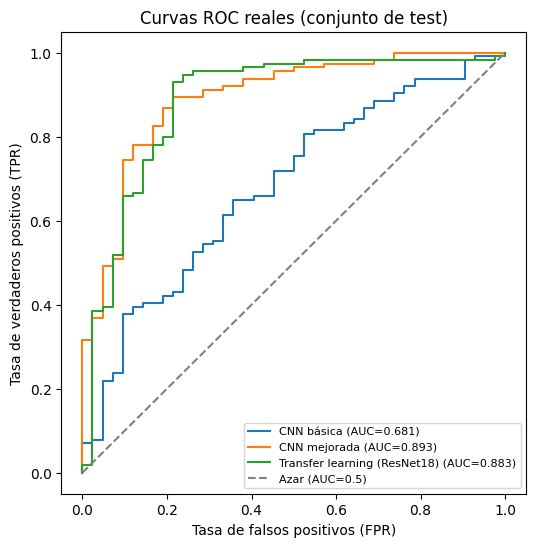

In [29]:
from sklearn.metrics import roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve

models_to_compare = {
    "CNN básica": (model_baseline, test_loader),
    "CNN mejorada": (model_improved, test_loader),
    "Transfer learning (ResNet18)": (resnet, test_loader_tl),
}

results = {}
for name, (m, loader) in models_to_compare.items():
    results[name] = evaluate(m, loader, nn.CrossEntropyLoss())

plt.figure(figsize=(6, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC reales (conjunto de test)")
plt.legend(fontsize=8)
plt.show()


**Interpretación:**
La curva ROC presenta algunos escalones debido a que BreastMNIST cuenta con pocas imágenes de prueba. Esto es normal, ya que cada imagen puede modificar ligeramente la curva cuando cambia el umbral de clasificación.  
Al comparar los modelos mediante el AUC, se observa que la CNN mejorada y el modelo con Transfer Learning tienen un mejor desempeño que la CNN básica, logrando una mayor capacidad para diferenciar entre las dos clases.

### 11.1. Diagrama de confiabilidad (calibración) antes de corregir


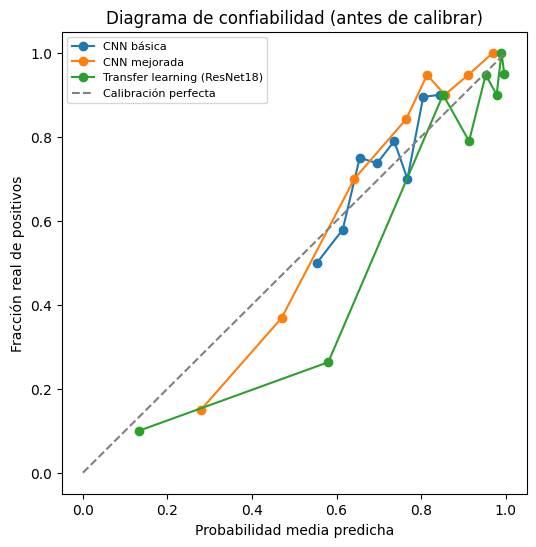

CNN básica                       | Brier score (antes de calibrar) = 0.1827
CNN mejorada                     | Brier score (antes de calibrar) = 0.1150
Transfer learning (ResNet18)     | Brier score (antes de calibrar) = 0.1110


In [30]:
plt.figure(figsize=(6, 6))
for name, res in results.items():
    frac_pos, mean_pred = calibration_curve(res["y_true"], res["y_prob"], n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Fracción real de positivos")
plt.title("Diagrama de confiabilidad (antes de calibrar)")
plt.legend(fontsize=8)
plt.show()

for name, res in results.items():
    bs = brier_score_loss(res["y_true"], res["y_prob"])
    print(f"{name:32s} | Brier score (antes de calibrar) = {bs:.4f}")


**Interpretación:**
El diagrama de confiabilidad permite evaluar qué tan cercanas están las probabilidades predichas por el modelo respecto a los resultados reales. Debido al tamaño reducido de BreastMNIST, se observan algunas variaciones respecto a la línea de calibración perfecta.  
Los valores de Brier Score muestran que la CNN mejorada y el modelo con Transfer Learning generan probabilidades más confiables que la CNN básica, presentando un menor error de calibración.

## 12. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante. **Grad-CAM** produce un mapa de calor sobre la imagen, indicando qué regiones influyeron más en la predicción. Lo aplicamos sobre el modelo de transfer learning (ResNet18).


In [31]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    target_layer = model.layer4[-1]
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    model.zero_grad()
    logits[0, target_class].backward()

    acts = activations["value"][0]
    grads = gradients["value"][0]
    weights = grads.mean(dim=(1, 2))

    cam = torch.zeros(acts.shape[1:], device=device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)
    cam = cam.detach().cpu().numpy()

    h1.remove()
    h2.remove()
    return cam, target_class


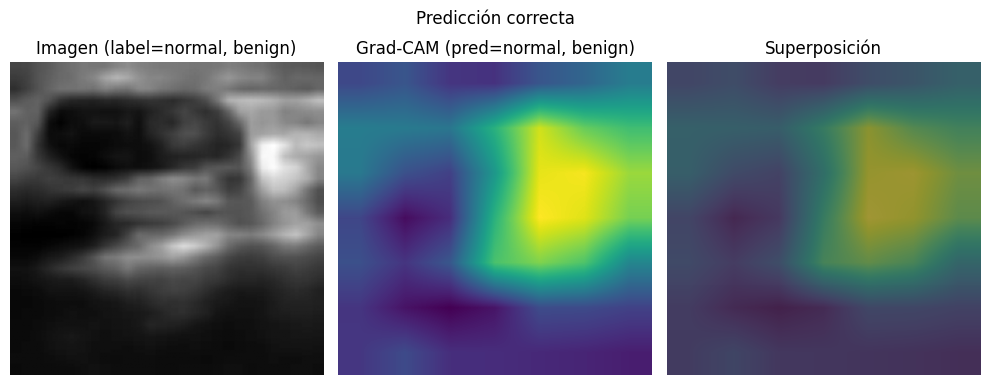

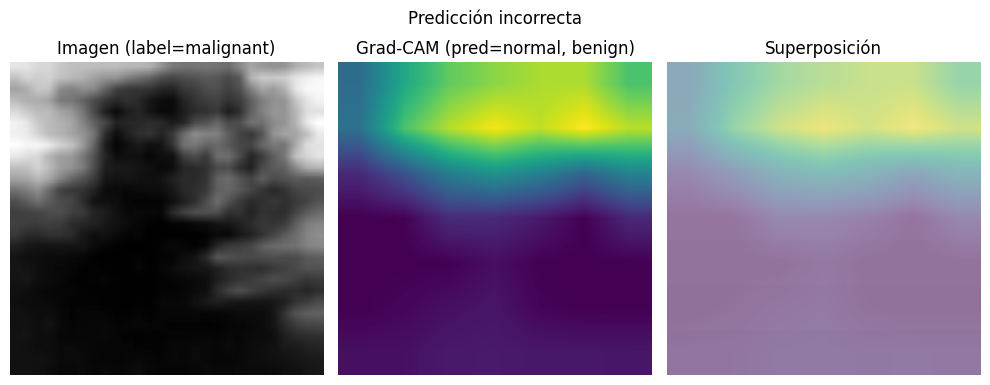

In [37]:
# Buscamos un caso correcto y uno incorrecto para comparar
resnet.eval()
correct_idx, wrong_idx = None, None
for i in range(len(test_dataset_tl)):
    x, y = test_dataset_tl[i]
    with torch.no_grad():
        pred = resnet(x.unsqueeze(0).to(device)).argmax(dim=1).item()
    if pred == int(y.item()) and correct_idx is None:
        correct_idx = i
    if pred != int(y.item()) and wrong_idx is None:
        wrong_idx = i
    if correct_idx is not None and wrong_idx is not None:
        break

for idx, titulo in [(correct_idx, "Predicción correcta"), (wrong_idx, "Predicción incorrecta")]:
    x, y = test_dataset_tl[idx]
    cam, pred_class = grad_cam(resnet, x)
    img = x[0].numpy()

    plt.figure(figsize=(10, 4))
    plt.suptitle(titulo)

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Imagen (label={info['label'][str(int(y.item()))]})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, interpolation="bilinear")
    plt.title(f"Grad-CAM (pred={info['label'][str(pred_class)]})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(cam, alpha=0.5, interpolation="bilinear")
    plt.title("Superposición")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 13. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas los casos malignos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.
- **Calibración (Brier score)**: qué tan confiables son las probabilidades reportadas.

3) Cuidado con sesgos:
- Diferencias por equipo de ecografía, operador, población.
- Etiquetas ruidosas.
- BreastMNIST es un dataset **muy chico** (780 imágenes en total): los resultados obtenidos acá tienen alta varianza y no deberían generalizarse sin más datos.

4) Validación externa:
- Probar en datos de otra fuente es clave antes de cualquier uso real.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 14. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [33]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_baseline.state_dict(), "models/cnn_baseline.pth")
torch.save(model_improved.state_dict(), "models/cnn_improved.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_baseline.pth", "models/cnn_improved.pth", "models/resnet_transfer.pth"]


['models/cnn_baseline.pth',
 'models/cnn_improved.pth',
 'models/resnet_transfer.pth']